# Direct Inverse Design Generation

Run the cells below to generate molecules.

The default paramaters will download QM9, train a GNN to predict the HOMO-LUMO gap and generate a molecule with a gap close to 4.1 eV.

Try it out!

In [1]:
# @title Installing dependencies (Colab only)
import torch

def format_pytorch_version(version):
  return version.split('+')[0]

TORCH_version = torch.__version__
TORCH = format_pytorch_version(TORCH_version)

def format_cuda_version(version):
  return 'cu' + version.replace('.', '')

CUDA_version = torch.version.cuda
CUDA = format_cuda_version(CUDA_version)

!pip install torch-scatter -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 70.6 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 22.8 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 17.9 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.8 MB/s eta 0:00:00


In [2]:
# @title Installing didgen
!git clone https://github.com/ftherrien/inv-design.git
%cd inv-design/
!pip install -e .

Cloning into 'inv-design'...
remote: Enumerating objects: 2577, done.
remote: Counting objects: 100% (2263/2263), done.
remote: Compressing objects: 100% (2243/2243), done.
remote: Total 2577 (delta 24), reused 2252 (delta 20), pack-reused 314 (from 1)
Receiving objects: 100% (2577/2577), 2.38 MiB | 15.75 MiB/s, done.
Resolving deltas: 100% (225/225), done.
/content/inv-design
Obtaining file:///content/inv-design
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 M

Extracting out_gen/qm9/raw/qm9.zip
Processing...
100%|██████████| 133885/133885 [03:00<00:00, 740.62it/s]
Done!


Size of database: 1000
0 AVG TRAIN MAE 2.647213363647461 AVG VALID MAE 1.441581815481186
1 AVG TRAIN MAE 1.02565744916598 AVG VALID MAE 0.6037075519561768
2 AVG TRAIN MAE 0.8568044662475586 AVG VALID MAE 0.43912698328495026
3 AVG TRAIN MAE 0.8079569896062215 AVG VALID MAE 0.45589881390333176
4 AVG TRAIN MAE 0.8016876796881358 AVG VALID MAE 0.461625300347805
5 AVG TRAIN MAE 0.7894477585951487 AVG VALID MAE 0.5622565597295761
6 AVG TRAIN MAE 0.7881245543559392 AVG VALID MAE 0.6636865884065628
7 AVG TRAIN MAE 0.7834771911303202 AVG VALID MAE 0.49988561123609543
8 AVG TRAIN MAE 0.792364963889122 AVG VALID MAE 0.6542304009199142
9 AVG TRAIN MAE 0.787272631128629 AVG VALID MAE 0.43673931807279587
10 AVG TRAIN MAE 0.7356286903222402 AVG VALID MAE 0.5113042593002319
11 AVG TRAIN MAE 0.7195653388897578 AVG VALID MAE 0.5148603767156601
12 AVG TRAIN MAE 0.7550860464572906 AVG VALID MAE 0.45790915191173553
13 AVG TRAIN MAE 0.7078249514102936 AVG VALID MAE 0.6076688766479492
14 AVG TRAIN MAE 0.7088

  7%|▋         | 21/300 [00:00<00:04, 56.45it/s]


Generation successful
Final property value: tensor([[4.0129]], grad_fn=<MulBackward0>)
Final property value after rounding: tensor([[4.0341]], grad_fn=<MulBackward0>)
Final property value after rounding (adj_r): tensor([[4.0162]], grad_fn=<MulBackward0>)
Final property value after rounding (fea_r): tensor([[4.0308]], grad_fn=<MulBackward0>)
Generated Molecule SMILES:
[H]C1=NOC(ON([H])ON([H])[H])=C1[H]
Number of atoms of each type:
tensor([5., 3., 3., 3., 0., 1.])


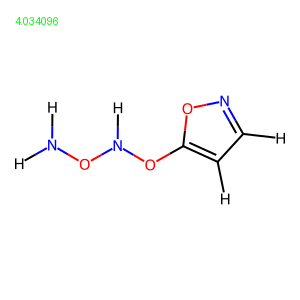

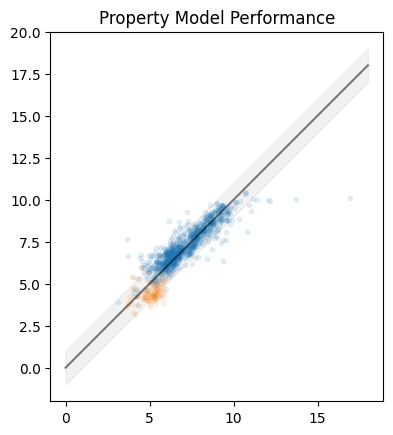

In [3]:
# @title Training and Generating
from didgen import generate
from IPython.display import Image, display
generate(1, "out_gen", {"max_size":15, "num_epochs": 100}, seed=0)
Image("out_gen/drawings/generated_mol_0.png")

Starting molecule generation loop
------------------------------------
Molecule 0:
Model estimate for starting point: tensor([[4.9938]], grad_fn=<MulBackward0>)
Generating molecule with requested property...


  7%|▋         | 20/300 [00:00<00:06, 40.55it/s]


Generation successful
Final property value: tensor([[4.0644]], grad_fn=<MulBackward0>)
Final property value after rounding: tensor([[4.0845]], grad_fn=<MulBackward0>)
Final property value after rounding (adj_r): tensor([[4.0661]], grad_fn=<MulBackward0>)
Final property value after rounding (fea_r): tensor([[4.0828]], grad_fn=<MulBackward0>)
Generated Molecule SMILES:
[H]C(=O)C1=C(N=C([H])N([H])[H])N=C=C1[H]
Number of atoms of each type:
tensor([5., 6., 3., 1., 0., 0.])
------------------------------------
Molecule 1:
Model estimate for starting point: tensor([[5.4486]], grad_fn=<MulBackward0>)
Generating molecule with requested property...


 26%|██▌       | 78/300 [00:02<00:07, 30.70it/s]


Generation successful
Final property value: tensor([[4.1459]], grad_fn=<MulBackward0>)
Final property value after rounding: tensor([[4.1974]], grad_fn=<MulBackward0>)
Final property value after rounding (adj_r): tensor([[4.1489]], grad_fn=<MulBackward0>)
Final property value after rounding (fea_r): tensor([[4.1946]], grad_fn=<MulBackward0>)
Generated Molecule SMILES:
[H]C1=C=C([H])C2=C1N=C([H])N2ON([H])[H]
Number of atoms of each type:
tensor([5., 6., 3., 1., 0., 0.])
------------------------------------
Molecule 2:
Model estimate for starting point: tensor([[5.8049]], grad_fn=<MulBackward0>)
Generating molecule with requested property...


...

Generated molecule is not stochiometric
------------------------------------
Molecule 3:
Model estimate for starting point: tensor([[6.6860]], grad_fn=<MulBackward0>)
Generating molecule with requested property...


 21%|██▏       | 64/300 [00:00<00:03, 64.68it/s]


Generation successful
Final property value: tensor([[4.2617]], grad_fn=<MulBackward0>)
Final property value after rounding: tensor([[4.2891]], grad_fn=<MulBackward0>)
Final property value after rounding (adj_r): tensor([[4.2673]], grad_fn=<MulBackward0>)
Final property value after rounding (fea_r): tensor([[4.2835]], grad_fn=<MulBackward0>)
Generated Molecule SMILES:
[H]N1C2=C3OC31N1OON1C2([H])[H]
Number of atoms of each type:
tensor([3., 4., 3., 3., 0., 2.])
------------------------------------
Molecule 4:
Model estimate for starting point: tensor([[4.6648]], grad_fn=<MulBackward0>)
Generating molecule with requested property...


  7%|▋         | 21/300 [00:00<00:04, 66.53it/s]

Generation successful
Final property value: tensor([[4.3703]], grad_fn=<MulBackward0>)
Final property value after rounding: tensor([[4.3878]], grad_fn=<MulBackward0>)
Final property value after rounding (adj_r): tensor([[4.3727]], grad_fn=<MulBackward0>)
Final property value after rounding (fea_r): tensor([[4.3853]], grad_fn=<MulBackward0>)
Generated Molecule SMILES:
[H]C#CC(=NO[H])C([H])=NC([H])=O
Number of atoms of each type:
tensor([4., 5., 2., 2., 0., 2.])


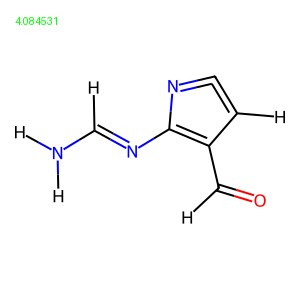

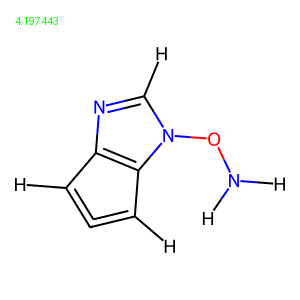

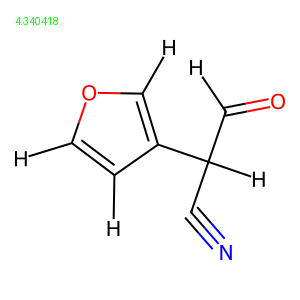

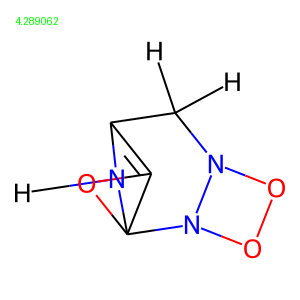

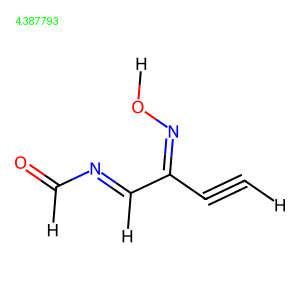

In [4]:
# @title Generating from trained model
generate(5, "out_gen", {"max_size":15, "num_epochs": 100, "use_pretrained":True}, seed=0)
display(Image("out_gen/drawings/generated_mol_0.png"))
display(Image("out_gen/drawings/generated_mol_1.png"))
display(Image("out_gen/drawings/generated_mol_2.png"))
display(Image("out_gen/drawings/generated_mol_3.png"))
display(Image("out_gen/drawings/generated_mol_4.png"))